# Recuperacion parcial de clave en AES-128 reducido a 3 rondas

Este notebook implementa el ataque diferencial usual: los pares se generan en el espacio de textos claros y recorren el cifrador completo. No se construyen pares sinteticos en estados intermedios.

La caracteristica usada se encuentra en `find_characteristics/aes_128_3round_characteristic.json`:

$$\mathtt{B30000000058000000004500000000F7}$$
$$\longrightarrow\mathtt{01000000000000000000000000000000}$$
$$\longrightarrow\mathtt{3E1F1F21000000000000000000000000}$$
$$\longrightarrow\mathtt{D10000000000009E0000A30000A30000}.$$

La probabilidad completa es $2^{-54}$ y su peso es 54.

## 1. Probabilidad para el key recovery

Para atacar la ultima subclave no es necesario exigir la transicion de la tercera S-box. Se necesita que el par alcance la entrada de la tercera ronda con diferencia

$$\Delta U=\mathtt{3E1F1F21000000000000000000000000}.$$

La probabilidad de las dos primeras rondas es

$$P_{\mathrm{prefijo}}=2^{-24}\cdot2^{-6}=2^{-30}.$$

Por tanto, se espera aproximadamente un par util por cada $2^{30}$ pares elegidos. Esta cantidad sigue siendo muy grande para un notebook, aunque sea mayor que $2^{-64}$.

El cuadernillo ejecuta el ataque con una muestra limitada y muestra de forma explicita si la cantidad de datos es suficiente.

## 2. Regla de conteo

La ultima ronda cumple

$$C_j=S(U_{\pi(j)})\oplus K_{3,j},$$

donde $\pi$ representa `ShiftRows`. Para un candidato $k$ se calcula

$$\widehat U_{\pi(j)}(k)=S^{-1}(C_j\oplus k).$$

El candidato recibe un punto cuando

$$\widehat U_{\pi(j)}(k)\oplus\widehat U'_{\pi(j)}(k)=\Delta U_{\pi(j)}.$$

In [1]:
from pathlib import Path
import json
import math
import random
import sys

import matplotlib.pyplot as plt
import pandas as pd


def add_repo_root_to_path():
    current = Path.cwd().resolve()
    for path in [current, *current.parents]:
        if (path / "cryptosystems").is_dir() and (path / "find_characteristics").is_dir():
            if str(path) not in sys.path:
                sys.path.insert(0, str(path))
            return path
    raise RuntimeError("No se encontro la raiz del repositorio")


ROOT = add_repo_root_to_path()
from cryptosystems.aes import INV_S_BOX
from cryptosystems.reduced_aes import ReducedAES

pd.set_option("display.max_columns", None)
print(f"Repo root: {ROOT}")

Repo root: C:\Users\juanc\github\Differential-Cryptanalysis-


## 3. Lectura de la caracteristica

Las probabilidades se calculan directamente desde los registros por ronda del JSON.

In [2]:
path = ROOT / "find_characteristics" / "aes_128_3round_characteristic.json"
characteristic = json.loads(path.read_text(encoding="utf-8"))
round_records = characteristic["rounds"]

DELTA_P = int(characteristic["initial_difference"], 16)
DELTA_U = int(round_records[-1]["input_difference"], 16)
FULL_TRAIL_PROBABILITY = float(characteristic["probability"])
PREFIX_PROBABILITY = math.prod(float(item["probability"]) for item in round_records[:-1])
PREFIX_WEIGHT = -math.log2(PREFIX_PROBABILITY)

rounds_df = pd.DataFrame([
    {
        "ronda": item["round"],
        "entrada": item["input_difference"],
        "salida": item["output_difference"],
        "S-boxes activas": item["active_sboxes"],
        "probabilidad": item["probability"],
        "peso": item["weight"],
    }
    for item in round_records
])

print(f"Probabilidad completa: {FULL_TRAIL_PROBABILITY:.12e} = 2^-54")
print(f"Probabilidad hasta Delta U: {PREFIX_PROBABILITY:.12e} = 2^-{PREFIX_WEIGHT:.0f}")
print(f"Delta U: 0x{DELTA_U:032X}")
rounds_df

Probabilidad completa: 5.551115123126e-17 = 2^-54
Probabilidad hasta Delta U: 9.313225746155e-10 = 2^-30
Delta U: 0x3E1F1F21000000000000000000000000


,ronda,entrada,salida,S-boxes activas,probabilidad,peso
0,1,0xB30000000058000000004500000000F7,0x01000000000000000000000000000000,4,5.960464e-08,24.0
1,2,0x01000000000000000000000000000000,0x3E1F1F21000000000000000000000000,1,1.562500e-02,6.0
2,3,0x3E1F1F21000000000000000000000000,0xD10000000000009E0000A30000A30000,4,5.960464e-08,24.0


## 4. Parametros y complejidad de datos

Se ejecutan $2^{16}$ pares reales. Con esta muestra, la cantidad esperada de pares que alcanzan $\Delta U$ es

$$2^{16}\cdot2^{-30}=2^{-14}.$$

Es decir, lo normal es no observar ningun par correcto. El experimento sirve para mostrar el procedimiento y cuantificar la insuficiencia de datos.

In [3]:
ROUNDS = 3
BLOCK_BITS = 128
KEY_BITS = 128
MASTER_KEY_HEX = "000102030405060708090A0B0C0D0E0F"
N_PAIRS = 1 << 16
SEED = 2026

cipher = ReducedAES(rounds=ROUNDS, block_bits=BLOCK_BITS, key_bits=KEY_BITS)
round_keys = cipher.expand_key_from_hex(MASTER_KEY_HEX)
true_last_round_key = round_keys[-1]

expected_right_pairs = N_PAIRS * PREFIX_PROBABILITY
pairs_for_one_expected = math.ceil(1 / PREFIX_PROBABILITY)
pairs_for_ten_expected = math.ceil(10 / PREFIX_PROBABILITY)

print(f"Pares ejecutados: {N_PAIRS:,}")
print(f"Pares correctos esperados: {expected_right_pairs:.8f}")
print(f"Pares para 1 acierto esperado: {pairs_for_one_expected:,}")
print(f"Pares para 10 aciertos esperados: {pairs_for_ten_expected:,}")

Pares ejecutados: 65,536
Pares correctos esperados: 0.00006104
Pares para 1 acierto esperado: 1,073,741,824
Pares para 10 aciertos esperados: 10,737,418,240


## 5. Posiciones atacadas

Los cuatro bytes activos de $\Delta U$ son desplazados por `ShiftRows`. Las posiciones recuperables de la subclave son 0, 7, 10 y 13.

In [4]:
delta_u_bytes = cipher._int_to_state(DELTA_U)
origin_by_output_position = list(range(cipher.block_bytes))
cipher._shift_rows(origin_by_output_position)
ACTIVE_OUTPUT_POSITIONS = [
    position
    for position, origin in enumerate(origin_by_output_position)
    if delta_u_bytes[origin] != 0
]

pd.DataFrame([
    {
        "salida j": position,
        "origen pi(j)": origin_by_output_position[position],
        "Delta U": f"0x{delta_u_bytes[origin_by_output_position[position]]:02X}",
    }
    for position in ACTIVE_OUTPUT_POSITIONS
])

,salida j,origen pi(j),Delta U
0,0,0,0x3E
1,7,3,0x21
2,10,2,0x1F
3,13,1,0x1F


## 6. Generacion y cifrado de pares reales

Cada par se construye como

$$P'=P\oplus\Delta P$$

y ambos bloques se cifran desde la primera ronda con AES reducido completo.

In [5]:
rng = random.Random(SEED)
ciphertext_byte_pairs = []
sample_rows = []

for index in range(N_PAIRS):
    p = rng.randrange(0, 1 << BLOCK_BITS)
    p_prime = p ^ DELTA_P
    c = cipher.encrypt_block(p, round_keys)
    c_prime = cipher.encrypt_block(p_prime, round_keys)
    ciphertext_byte_pairs.append((cipher._int_to_state(c), cipher._int_to_state(c_prime)))
    if index < 5:
        sample_rows.append({
            "P": f"0x{p:032X}",
            "P'": f"0x{p_prime:032X}",
            "C": f"0x{c:032X}",
            "C'": f"0x{c_prime:032X}",
        })

pd.DataFrame(sample_rows)

,P,P',C,C'
0,0x3D6C51E370EB9A0A96263AE6C5E818FA,0x8E6C51E370B39A0A96267FE6C5E8180D,0x811BCD79C8085F144FB6E18222D5BC02,0x052016CDA5A87DD00B8736BEDCCEF80B
1,0x5071950EADEC6F117D836E77AF67D461,0xE371950EADB46F117D832B77AF67D496,0x6BDDDB13C3EC671C5D50E0E3BC231218,0x4FCE2FC11911C0B35C056A57E8970282
2,0x89BE9C1C8EB5140F16F4488157241955,0x3ABE9C1C8EED140F16F40D81572419A2,0x004CC70015DAB3064B4AD9C5CA82DD3C,0xFDF62A51526573E9DDE5A6DD7B80F1FD
3,0x4F1A8A1D93D20470B766FF10B437BDB5,0xFC1A8A1D938A0470B766BA10B437BD42,0x442B6FFF084DAE58D9575ABC3B147A3A,0xBDBA43C0F9793D3ABFC8B3252C319DFD
4,0x5D111A9D5E6C9992B5FB12E0D9090B89,0xEE111A9D5E349992B5FB57E0D9090B7E,0xF516949EF110B862646598910CDA6052,0x3F1ECA80C083294549C69DBC000A3657


## 7. Conteo de candidatos

Se prueban los 256 valores posibles en cada byte activo. No se usa informacion del estado intermedio real.

In [6]:
def score_candidate(key_guess: int, output_position: int) -> int:
    origin = origin_by_output_position[output_position]
    target_delta = delta_u_bytes[origin]
    score = 0
    for c_bytes, c_prime_bytes in ciphertext_byte_pairs:
        u_hat = INV_S_BOX[c_bytes[output_position] ^ key_guess]
        u_hat_prime = INV_S_BOX[c_prime_bytes[output_position] ^ key_guess]
        if (u_hat ^ u_hat_prime) == target_delta:
            score += 1
    return score


scores_by_position = {}
for position in ACTIVE_OUTPUT_POSITIONS:
    rows = [
        {
            "candidate_int": key_guess,
            "candidato": f"0x{key_guess:02X}",
            "score": score_candidate(key_guess, position),
        }
        for key_guess in range(256)
    ]
    scores_by_position[position] = pd.DataFrame(rows).sort_values(
        ["score", "candidate_int"], ascending=[False, True]
    ).reset_index(drop=True)

pd.concat([
    df.head(5).assign(posicion=position, ranking=range(1, 6))
    for position, df in scores_by_position.items()
])[["posicion", "ranking", "candidato", "score"]]

,posicion,ranking,candidato,score
0,0,1,0x7E,315
1,0,2,0xEE,297
2,0,3,0x16,294
3,0,4,0x56,292
4,0,5,0x9F,288
0,7,1,0x2D,300
1,7,2,0x06,298
2,7,3,0xCA,293
3,7,4,0x10,290
4,7,5,0x52,287


## 8. Evaluacion del ranking

En un experimento exitoso, el byte real debe ocupar el primer lugar con un margen positivo. Con $2^{16}$ pares, la cantidad esperada de pares correctos es casi cero, por lo que no se espera recuperar la clave.

In [7]:
true_key_bytes = cipher._int_to_state(true_last_round_key)
result_rows = []

for position in ACTIVE_OUTPUT_POSITIONS:
    df = scores_by_position[position]
    true_byte = true_key_bytes[position]
    true_row = df[df["candidate_int"] == true_byte].iloc[0]
    true_rank = int(df.index[df["candidate_int"] == true_byte][0]) + 1
    result_rows.append({
        "posicion": position,
        "mejor candidato": df.iloc[0]["candidato"],
        "byte real": f"0x{true_byte:02X}",
        "score real": int(true_row["score"]),
        "rango real": true_rank,
        "recuperado": true_rank == 1,
    })

result_df = pd.DataFrame(result_rows)
result_df

,posicion,mejor candidato,byte real,score real,rango real,recuperado
0,0,0x7E,0xB6,266,61,False
1,7,0x2D,0xBF,266,81,False
2,10,0xC8,0x0C,266,64,False
3,13,0x0E,0x69,266,79,False


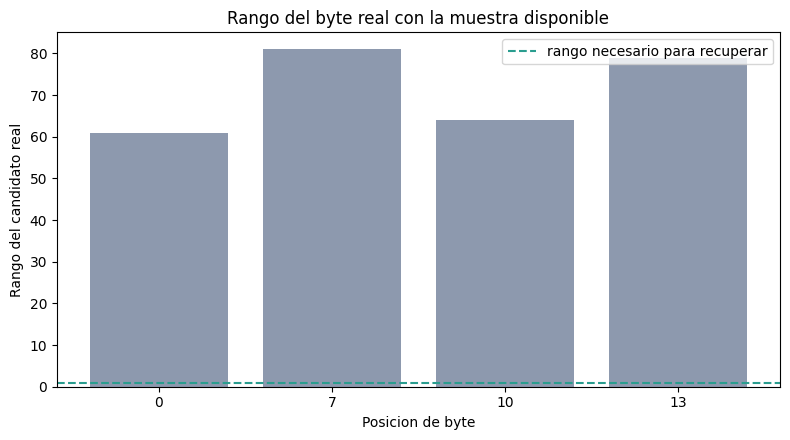

In [8]:
plt.figure(figsize=(8, 4.5))
plt.bar(result_df["posicion"].astype(str), result_df["rango real"], color="#8D99AE")
plt.axhline(1, color="#2A9D8F", linestyle="--", label="rango necesario para recuperar")
plt.title("Rango del byte real con la muestra disponible")
plt.xlabel("Posicion de byte")
plt.ylabel("Rango del candidato real")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Conclusion

El ataque fue ejecutado con pares reales, pero $2^{16}$ pares son muy inferiores a los aproximadamente $2^{30}$ necesarios para observar un par que alcance la diferencia de entrada de la ultima ronda.

Por ello, los rankings obtenidos son dominados por ruido y no constituyen una recuperacion valida de la subclave.

Esto no indica un error en el algoritmo. Muestra la complejidad de datos real asociada a la caracteristica.